In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import f_oneway
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Load the aggregated weekly defect dataset.
candidate_files = [Path("anova_defects_per_week.csv"), Path("anova_defects_per_week(1).csv")]
csv_path = next((path for path in candidate_files if path.exists()), None)
if csv_path is None:
    raise FileNotFoundError("Place anova_defects_per_week.csv in the same folder as this notebook.")

df = pd.read_csv(csv_path)
df = df.rename(columns={"Count of Defect Type": "Defect_Count"})

required_columns = {"Inspection Week", "Production Model", "Defect_Count"}
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f"Missing required columns: {sorted(missing_columns)}")

df.head()

,Inspection Week,Production Model,Defect_Count
0,2025-W01,Model 595130-195,7
1,2025-W02,Model 595130-195,8
2,2025-W03,Model 595130-195,6
3,2025-W04,Model 595130-195,9
4,2025-W05,Model 595130-195,7


In [2]:
# Use exact model labels rather than loose string matching.
model_ids = ["595130-195", "595214-125", "595242-854"]
model_labels = [f"Model {model_id}" for model_id in model_ids]

groups = [
    df.loc[df["Production Model"].eq(model_label), "Defect_Count"].dropna().to_numpy()
    for model_label in model_labels
]

sample_sizes = dict(zip(model_labels, [len(group) for group in groups]))
sample_sizes

{'Model 595130-195': 52, 'Model 595214-125': 52, 'Model 595242-854': 52}

In [3]:
summary = (
    df[df["Production Model"].isin(model_labels)]
    .groupby("Production Model")["Defect_Count"]
    .agg(n="count", total="sum", mean="mean", median="median", std="std", min="min", max="max")
    .loc[model_labels]
)
summary

,n,total,mean,median,std,min,max
Production Model,,,,,,,
Model 595130-195,52,361,6.942308,7.0,1.258905,5,10
Model 595214-125,52,320,6.153846,6.0,1.564115,3,11
Model 595242-854,52,273,5.250000,5.0,1.519481,2,9


In [4]:
f_stat, p_value = f_oneway(*groups)
alpha = 0.05
decision = "Reject H0" if p_value <= alpha else "Fail to reject H0"

print(f"One-way ANOVA: F(2, {sum(len(g) for g in groups) - len(groups)}) = {f_stat:.2f}")
print(f"p-value = {p_value:.3g}")
print(f"Decision at alpha={alpha}: {decision}")

One-way ANOVA: F(2, 153) = 17.64
p-value = 1.27e-07
Decision at alpha=0.05: Reject H0


## Boxplot: Weekly defect counts by production model

This plot visually supports the ANOVA result by showing that weekly defect counts differ across the three production models. Model 595130-195 has the highest median and mean weekly defect count, making it the strongest initial improvement target. Model 595214-125 shows more volatility, including higher weekly spikes, while Model 595242-854 has the lowest center overall.

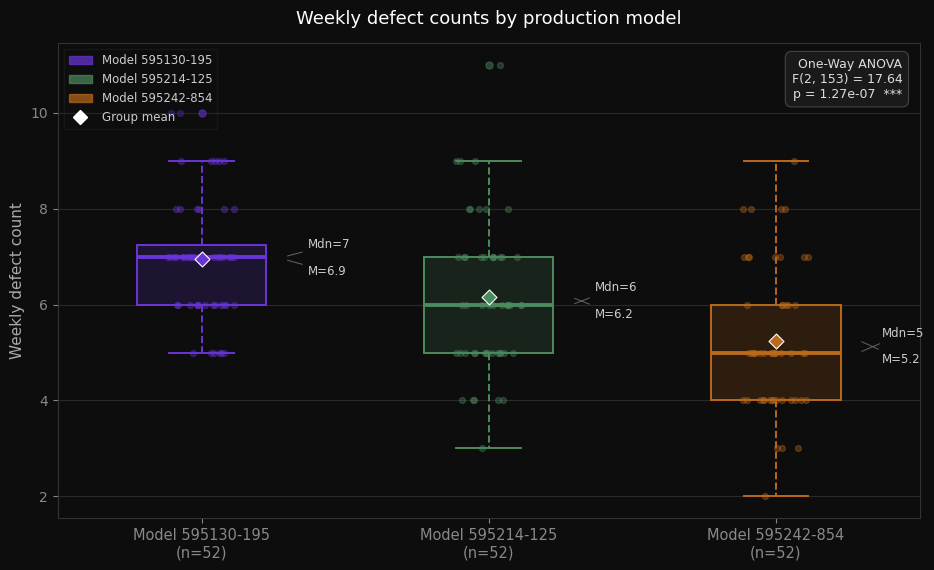

Saved → boxplot_anova_output.png


In [5]:
# Portfolio-ready boxplot that uses the calculated ANOVA result above.
# The chart shows distribution, individual weekly observations, median, mean, and sample size.

palette = ["#6A35D8", "#4C8B5E", "#B96A1B"]
face_rgba = [(106/255, 53/255, 216/255, 0.18), (76/255, 139/255, 94/255, 0.18), (185/255, 106/255, 27/255, 0.18)]

fig, ax = plt.subplots(figsize=(9.5, 5.8))
fig.patch.set_facecolor("#0d0d0d")
ax.set_facecolor("#0d0d0d")

for spine in ax.spines.values():
    spine.set_edgecolor("#333333")

bp = ax.boxplot(groups, patch_artist=True, widths=0.45, medianprops=dict(linewidth=2.8),
                whiskerprops=dict(linewidth=1.4, linestyle="--"), capprops=dict(linewidth=1.4),
                flierprops=dict(marker="o", markersize=5, linestyle="none"), boxprops=dict(linewidth=1.4))

for box, fc, ec in zip(bp["boxes"], face_rgba, palette):
    box.set_facecolor(fc); box.set_edgecolor(ec)
for median, ec in zip(bp["medians"], palette):
    median.set_color(ec)
for whisker, ec in zip(bp["whiskers"], np.repeat(palette, 2)):
    whisker.set_color(ec)
for cap, ec in zip(bp["caps"], np.repeat(palette, 2)):
    cap.set_color(ec)
for flier, ec in zip(bp["fliers"], palette):
    flier.set_markerfacecolor(ec); flier.set_markeredgecolor(ec); flier.set_alpha(0.45)

rng = np.random.default_rng(42)
for i, (group, ec) in enumerate(zip(groups, palette), start=1):
    jitter = rng.uniform(-0.12, 0.12, size=len(group))
    ax.scatter(np.full(len(group), i) + jitter, group, color=ec, alpha=0.35, s=18, zorder=3)

for i, (group, ec) in enumerate(zip(groups, palette), start=1):
    ax.scatter(i, np.mean(group), marker="D", s=58, color=ec, zorder=5,
               edgecolors="white", linewidths=0.8)

min_sep = 0.55
for i, group in enumerate(groups, start=1):
    median_value = float(np.median(group)); mean_value = float(np.mean(group)); x_anchor = i + 0.29
    y_median = median_value; y_mean = mean_value
    if abs(median_value - mean_value) < min_sep:
        midpoint = (median_value + mean_value) / 2
        y_median = midpoint + min_sep / 2; y_mean = midpoint - min_sep / 2
    ax.annotate(f"Mdn={median_value:.0f}", xy=(x_anchor, median_value), xytext=(x_anchor + 0.08, y_median),
                fontsize=8.5, color="#cccccc", va="center", arrowprops=dict(arrowstyle="-", color="#666666", lw=0.7))
    ax.annotate(f"M={mean_value:.1f}", xy=(x_anchor, mean_value), xytext=(x_anchor + 0.08, y_mean),
                fontsize=8.5, color="#cccccc", va="center", arrowprops=dict(arrowstyle="-", color="#666666", lw=0.7))

df_between = len(groups) - 1
df_within = sum(len(group) for group in groups) - len(groups)
stats_text = f"One-Way ANOVA\nF({df_between}, {df_within}) = {f_stat:.2f}\np = {p_value:.2e}  ***"
ax.text(0.98, 0.97, stats_text, transform=ax.transAxes, fontsize=9, verticalalignment="top",
        horizontalalignment="right", color="#dddddd",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="#1a1a1a", edgecolor="#444444", linewidth=0.8))

x_tick_labels = [f"{label}\n(n={len(group)})" for label, group in zip(model_labels, groups)]
ax.set_xticks([1, 2, 3]); ax.set_xticklabels(x_tick_labels, fontsize=10.5, color="#cccccc")
ax.set_ylabel("Weekly defect count", fontsize=11, color="#cccccc")
ax.set_title("Weekly defect counts by production model", fontsize=13, fontweight="normal", color="#ffffff", pad=14)
ax.tick_params(colors="#888888"); ax.yaxis.label.set_color("#aaaaaa")
ax.grid(axis="y", color="#2a2a2a", linewidth=0.8, zorder=0)

patches = [mpatches.Patch(facecolor=color, edgecolor=color, label=label, alpha=0.7) for color, label in zip(palette, model_labels)]
mean_marker = plt.Line2D([0], [0], marker="D", color="none", markerfacecolor="white", markeredgecolor="white", markersize=7, label="Group mean")
ax.legend(handles=patches + [mean_marker], loc="upper left", fontsize=8.5, framealpha=0.2,
          edgecolor="#444444", labelcolor="#cccccc", facecolor="#111111")

plt.tight_layout()
output_path = "boxplot_anova_output.png"
plt.savefig(output_path, dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Saved → {output_path}")

### Portfolio caption suggestion

ANOVA indicated a statistically significant difference in weekly defect counts across production models, F(2, 153) = 17.64, p < .001. Model 595130-195 had the highest median weekly defect count, making it the strongest initial target for process improvement, while Model 595214-125 showed greater week-to-week variability.